#### **Understanding 1D convolution for sequence data**

1D convolutional layers can recognize local patterns in a sequence.It is translational invariant (for temporal translations), as a pattern learned by 1D convnet at a certain position in a sentence can later be recognized at a different position.

Let's build a simple two-layer 1D convnet and apply it to the IMDB sentiment classification task.

In [ ]:
### Preparing the IMDB data

from keras.datasets import imdb
from keras.preprocessing import sequence

max_features = 10000
max_len = 500

print("loading data...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words = max_features)
print("train sequences: ", len(x_train))
print("test sequences: ", len(x_test))

print("Pad sequences (sample x time)")
x_train = sequence.pad_sequences(x_train, maxlen=max_len)
x_test = sequence.pad_sequences(x_test, maxlen=max_len)
print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)

loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train sequences:  25000
test sequences:  25000
Pad sequences (sample x time)
x_train shape:  (25000, 500)
x_test shape:  (25000, 500)


In [ ]:
### Training and evaluating a simple 1D convnet on the IMDB data

from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop

model = Sequential()
model.add(layers.Embedding(max_features, 128, input_length=max_len))
model.add(layers.Conv1D(32, 7, activation='relu'))
model.add(layers.MaxPooling1D(5))
model.add(layers.Conv1D(32, 7, activation='relu'))
model.add(layers.GlobalMaxPooling1D())
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

model.compile(optimizer=RMSprop(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['acc'])

history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - acc: 0.5102 - loss: 0.6928 - val_acc: 0.5084 - val_loss: 0.6928
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - acc: 0.5520 - loss: 0.6911 - val_acc: 0.5178 - val_loss: 0.6919
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - acc: 0.6137 - loss: 0.6889 - val_acc: 0.6098 - val_loss: 0.6895
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - acc: 0.6793 - loss: 0.6850 - val_acc: 0.6414 - val_loss: 0.6844
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - acc: 0.6865 - loss: 0.6753 - val_acc: 0.6906 - val_loss: 0.6680
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - acc: 0.7183 - loss: 0.6457 - val_acc: 0.7324 - val_loss: 0.6179
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - acc: 0.7557 - loss: 0.5797 - val_acc: 0.7658 - val_loss: 0.5404
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.7904 - loss: 0.5006 - val_acc: 0.7984 - val_loss: 0.4706
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms

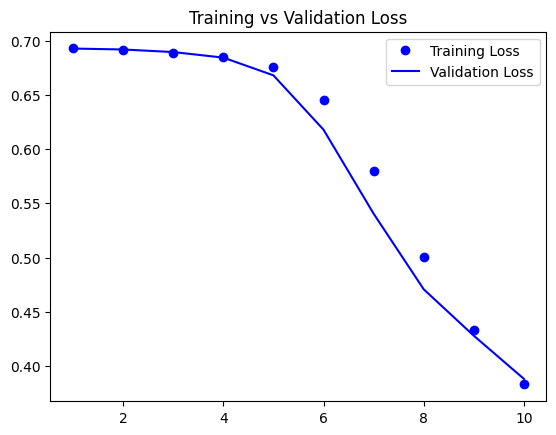

In [ ]:
### Plotting Results
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, 11)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

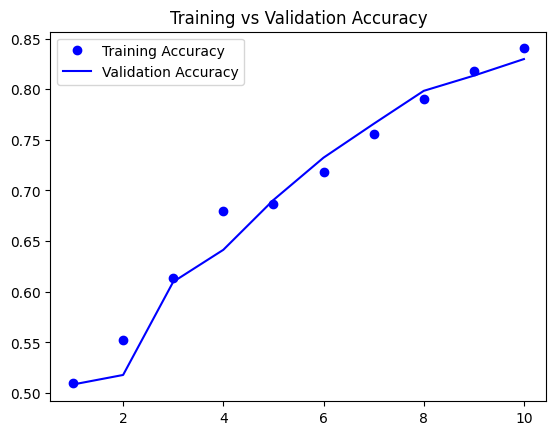

In [ ]:
### Plotting Results
import matplotlib.pyplot as plt

loss = history.history['acc']
val_loss = history.history['val_acc']

epochs = range(1, 11)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Accuracy')
plt.plot(epochs, val_loss, 'b', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

This is a convincing demonstration that a 1D convnet can offer a fast, cheap alternative to a recurrent network  on a word-level sentiment-classification task.

However, 1D convnets process input patches independently, they aren't sensitive to the order of the timesteps (beyond a local scale, the size of the convolution windows). To recognize longer term patterns, we can stack many convolution layers andd pooling layers, resulting in upper layers that will see long chunks of the original inputs --- but that's fairly weak way to induce order sensitivity.

In [ ]:
%mkdir jena_climate
%cd jena_climate/
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

/content/jena_climate
--2026-06-16 18:43:05--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.253.226, 16.15.246.252, 16.15.223.171, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.253.226|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  17.4MB/s    in 0.7s    

2026-06-16 18:43:06 (17.4 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [ ]:
### Inspeacting the data of the Jena weather dataset
import os


fname = '/content/jena_climate/jena_climate_2009_2016.csv'

f = open(fname)
data = f.read()
f.close()

lines = data.split('\n')
header = lines[0].split(',')
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [ ]:
### Parsing the data
import numpy as np

float_data = np.zeros((len(lines), len(header) -1))
for i, line in enumerate(lines):
  values = [float(x) for x in line.split(',')[1:]]
  float_data[i, :] = values

In [ ]:
### Normalizing the data (As the temperature in degree celcius but pressure in 1000mbar)

mean = float_data[:200000].mean(axis = 0)
float_data -= mean
std = float_data[:200000].std(axis=0)
float_data /= std

In [ ]:
### Generator yielding timeseries samples and their targets

def generator(data, lookback, delay, min_index, max_index, shuffle=False, batch_size=128, step=6):
  if max_index is None:
    max_index = len(data) - delay - 1
  i = min_index + lookback

  while 1:
    if shuffle:
      rows = np.random.randint(min_index + lookback, max_index, size=batch_size)
    else:
      if i + batch_size >= max_index:
        i = min_index + lookback
      rows = np.arange(i, min(i + batch_size, max_index))
      i += len(rows)
    samples = np.zeros((len(rows), lookback // step, data.shape[-1]))
    targets = np.zeros((len(rows),))

    for j, row in enumerate(rows):
      indices = range(rows[j] - lookback, rows[j], step)
      samples[j] = data[indices]
      targets[j] = data[rows[j] + delay][1]

    yield samples, targets #pauses the function's execution and returns a value temporarily

In [ ]:
### Preparing the training, validation, and test generators

lookback = 1440
step = 6 #1 hour
delay = 144 # one day
batch_size = 64

train_gen = generator(float_data, lookback=lookback, delay=delay, min_index=0, max_index=200000,
                      shuffle = True, step = step, batch_size = batch_size)

val_gen = generator(float_data, lookback=lookback, delay=delay, min_index=200001, max_index=300000,
                    step=step, batch_size=batch_size)

test_gen = generator(float_data, lookback=lookback, delay=delay, min_index=300001, max_index=None,
                     step = step, batch_size=batch_size)

val_steps = (300000 - 200001 - lookback)
test_steps = (len(float_data) - 300001 - lookback)

In [ ]:
### Training and evaluating a simple 1D convnet on the jena data

from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop

model = Sequential()
model.add(layers.Conv1D(32, 5, activation='relu', input_shape=(None, float_data.shape[-1])))
model.add(layers.MaxPooling1D(3))
model.add(layers.Conv1D(32, 5, activation='relu'))
model.add(layers.GlobalMaxPooling1D())
model.add(layers.Dense(1))

model.compile(optimizer=RMSprop(), loss='mse')

# Calculate steps for training and validation
train_steps = (200000 - lookback) // batch_size
val_steps_actual = (300000 - 200001 - lookback) // batch_size # Corrected val_steps based on generator logic

history = model.fit(train_gen, steps_per_epoch=train_steps, epochs=10, validation_data=val_gen, validation_steps=val_steps_actual)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 0.2423 - val_loss: 0.3107
Epoch 2/10
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 0.1869 - val_loss: 0.3334
Epoch 3/10
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 0.1696 - val_loss: 0.3300
Epoch 4/10
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 0.1587 - val_loss: 0.3304
Epoch 5/10
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 0.1491 - val_loss: 0.3460
Epoch 6/10
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 0.1431 - val_loss: 0.3344
Epoch 7/10
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 0.1388 - val_loss: 0.3523
Epoch 8/10
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 0.1358 - val_loss: 0.3900
Epoch 9/10
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 0.1318 - val_loss: 0.4091
Epoch 10/10
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 0.1300 - val_loss: 0.3793


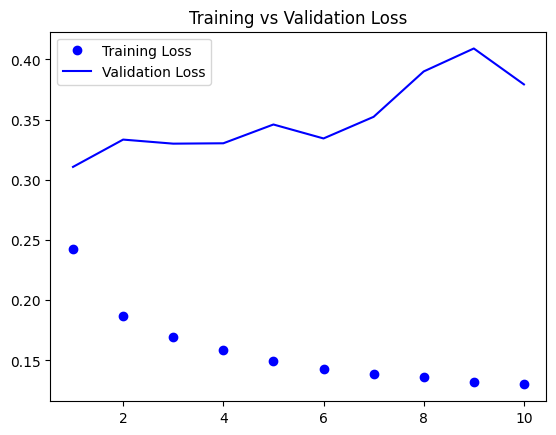

In [ ]:
### Plotting Results
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, 11)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

Huge Overfitting!!! We can't even beat the common-sense baseline using the small convnet. This is because the convnet looks for patterns anywhere in the input timeseries and has no knowledge of the temporal position of a pattern it sees (toward the beginning, toward the end, and so on). Because more recent data points should be interpreted differently from older data points for forecasting.

This limitation of convnets isn't an issue with the IMDB data, because patterns of keywords associated with a positive or negative sentiment are informative independently.

#### **Combining CNNs and RNNs to process long sequences**

One strategy to combine the speed and lightness of convnets with the order-sensitivity of RNNs is to use a 1D convnet as a preprocessing step before an RNN.

In [ ]:
### Preparing higher-resolution data generators for the Jena dataset

lookback = 720
step = 3 #1 hour 30 minutes
delay = 144 # one day
batch_size = 64

train_gen = generator(float_data, lookback=lookback, delay=delay, min_index=0, max_index=200000,
                      shuffle = True, step = step, batch_size = batch_size)

val_gen = generator(float_data, lookback=lookback, delay=delay, min_index=200001, max_index=300000,
                    step=step, batch_size=batch_size)

test_gen = generator(float_data, lookback=lookback, delay=delay, min_index=300001, max_index=None,
                     step = step, batch_size=batch_size)

val_steps = (300000 - 200001 - lookback)
test_steps = (len(float_data) - 300001 - lookback)

In [ ]:
### Model combining a 1D convolutional base and a GRU layer

from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop

model = Sequential()
model.add(layers.Conv1D(32, 5, activation='relu', input_shape=(None, float_data.shape[-1])))
model.add(layers.MaxPooling1D(3))
model.add(layers.Conv1D(32, 5, activation='relu'))
model.add(layers.GRU(32, dropout=0.1, recurrent_dropout=0.5))
model.add(layers.Dense(1))

model.summary()

model.compile(optimizer=RMSprop(), loss='mse')

# Recalculate steps for the new lookback and step values
new_lookback = 720
new_batch_size = 64

train_steps_new = (200000 - new_lookback) // new_batch_size
val_steps_new = (300000 - 200001 - new_lookback) // new_batch_size

history = model.fit(train_gen, steps_per_epoch=train_steps_new, epochs=10, validation_data=val_gen, validation_steps=val_steps_new)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, None, 32)       │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, None, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, None, 32)       │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,793 (53.88 KB)

 Trainable params: 13,793 (53.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 840s 268ms/step - loss: 0.1475 - val_loss: 0.1264
Epoch 2/10
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 809s 260ms/step - loss: 0.1148 - val_loss: 0.1262
Epoch 3/10
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 810s 260ms/step - loss: 0.0992 - val_loss: 0.1339
Epoch 4/10
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 807s 259ms/step - loss: 0.0873 - val_loss: 0.1463
Epoch 5/10
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 863s 277ms/step - loss: 0.0788 - val_loss: 0.1541
Epoch 6/10
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 862s 277ms/step - loss: 0.0733 - val_loss: 0.1574
Epoch 7/10
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 807s 259ms/step - loss: 0.0682 - val_loss: 0.1591
Epoch 8/10
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 795s 255ms/step - loss: 0.0648 - val_loss: 0.1546
Epoch 9/10
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 789s 253ms/step - loss: 0.0624 - val_loss: 0.1576
Epoch 10/10
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 792s 254ms/step - loss: 0.0598 - val_loss: 0.1613


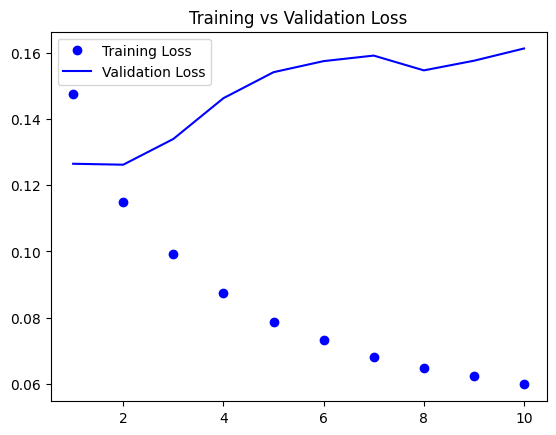

In [ ]:
### Plotting Results
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, 11)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

Judging from the validation loss, this setup isn't as good as the regularized GRU alone, but its significantly faster . It looks at twice as much data, which in this case doesn't appear to be hugely helpful but may be important for other datasets.